In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import *

(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 36s 0us/step


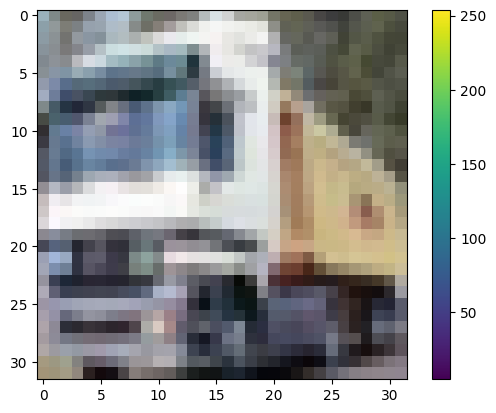

In [3]:
plt.figure()
plt.imshow(X_train[1])
plt.colorbar()

X_train = X_train/255.0
X_test = X_test/255.0

In [4]:
model = Sequential()
model.add(Conv2D(64, activation='relu', kernel_size=(3,3,)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(32, activation='relu', kernel_size=(3,3,)))
model.add(Flatten(input_shape = (32,32,3)))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

c:\Users\June\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=10, verbose=1, validation_split=0.3)

Epoch 1/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.4356 - loss: 1.5604 - val_accuracy: 0.5158 - val_loss: 1.3614
Epoch 2/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.5651 - loss: 1.2305 - val_accuracy: 0.5661 - val_loss: 1.2201
Epoch 3/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.6119 - loss: 1.0953 - val_accuracy: 0.5839 - val_loss: 1.1739
Epoch 4/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.6435 - loss: 1.0100 - val_accuracy: 0.6131 - val_loss: 1.1008
Epoch 5/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.6669 - loss: 0.9433 - val_accuracy: 0.6208 - val_loss: 1.0746
Epoch 6/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.6888 - loss: 0.8804 - val_accuracy: 0.6323 - val_loss: 1.0729
Epoch 7/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.7091 - loss: 0.8270 - val_accuracy: 0.6343 - val_loss: 1.0673
Epoch 8/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.7275 -

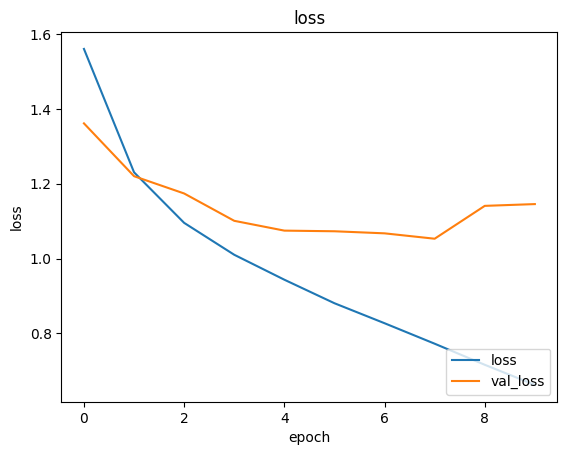

In [6]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['loss','val_loss'], loc='lower right')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
정답= [3]
예측값= [8.5171021e-04 1.3773819e-04 2.9742478e-03 8.4107214e-01 4.1541908e-04
 1.5042087e-01 2.3852829e-03 6.4607026e-05 1.2895061e-03 3.8844923e-04]


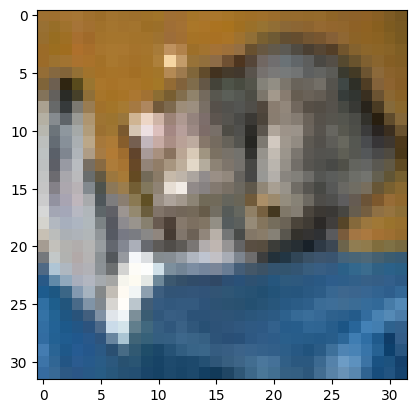

In [7]:
plt.figure()
plt.imshow(X_test[0])
y_pred = model.predict(X_test)
print('정답=',y_test[0])
print('예측값=', y_pred[0])